# Scenario 5 – SMOTE

## Importing the Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from sklearn.metrics import precision_recall_curve

## Loading the Dataset

In [2]:
df = pd.read_csv('/content/fraud_smote.csv')

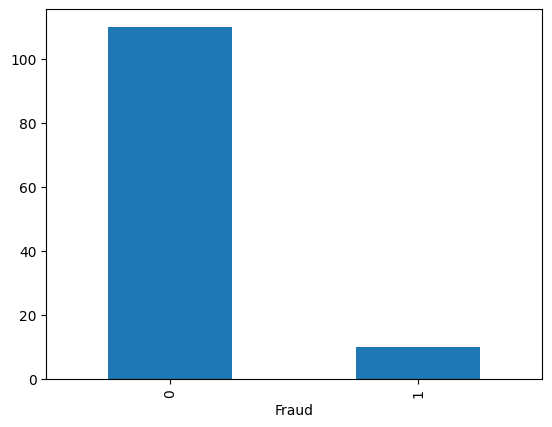

In [4]:
df['Fraud'].value_counts().plot(kind='bar')
plt.show()

## Model Train before SMOTE

In [11]:
target_col = 'Fraud'

X = df.drop(target_col, axis=1)
y = df[target_col]
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [12]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

## Apply SMOTE

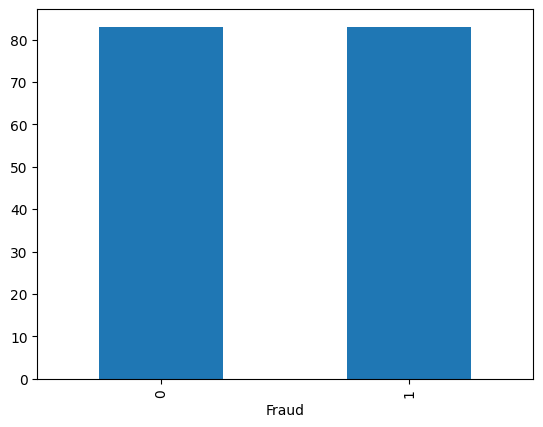

In [13]:
sm = SMOTE()
X_sm, y_sm = sm.fit_resample(X_train, y_train)
pd.Series(y_sm).value_counts().plot(kind='bar')
plt.show()

## Model Train after SMOTE

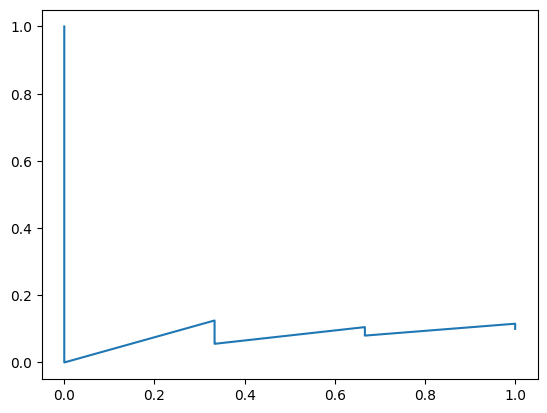

In [14]:
model.fit(X_sm, y_sm)
y_scores = model.predict_proba(X_test)[:,1]
precision, recall, _ = precision_recall_curve(y_test, y_scores)
plt.plot(recall, precision)
plt.show()